# Beijing Air Quality Analysis
**Nama:** Muhamad Rizki Rifaldi  


Proyek ini menganalisis kualitas udara di berbagai stasiun pemantauan di Beijing, China, menggunakan dataset PRSA (2013–2017). Analisis mencakup eksplorasi data, visualisasi, pengelompokan kualitas udara berdasarkan AQI PM2.5, dan pemetaan geospasial.

---
## 1. Import & Setup

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium

warnings.filterwarnings('ignore')

# Plot defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('husl')

# Data directory — adjust path if needed
DATA_DIR = '../Air-quality-dataset/PRSA_Data_20130301-20170228/'

# Load and merge all CSV files
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'Found {len(csv_files)} station files:')
for f in csv_files:
    print(' ', os.path.basename(f))

df_list = [pd.read_csv(f) for f in csv_files]
df_raw = pd.concat(df_list, ignore_index=True)

print(f'\nMerged DataFrame shape: {df_raw.shape}')
df_raw.head()

C:\Users\kinga\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.1.0) or chardet (7.1.0)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


Found 12 station files:
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv



Merged DataFrame shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


---
## 2. Data Wrangling

### 2a. Gathering Data

In [2]:
print('Shape:', df_raw.shape)
print('\nColumns:', df_raw.columns.tolist())
print('\nDtypes:')
print(df_raw.dtypes)
df_raw.head(10)

Shape: (420768, 18)

Columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Dtypes:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
5,6,2013,3,1,5,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin
6,7,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Aotizhongxin
7,8,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Aotizhongxin
8,9,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Aotizhongxin
9,10,2013,3,1,9,3.0,8.0,12.0,28.0,400.0,59.0,1.2,1028.5,-19.3,0.0,N,2.6,Aotizhongxin


**Insight — Gathering Data:**  
Dataset gabungan berisi **420,768 baris** dan **18 kolom** yang mencakup:
- **Kolom waktu:** `No`, `year`, `month`, `day`, `hour`
- **Polutan udara:** `PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`
- **Variabel meteorologi:** `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, `WSPM`
- **Identitas stasiun:** `station`

Data mencakup 12 stasiun pemantauan di Beijing dari Maret 2013 hingga Februari 2017 (4 tahun, per jam).

### 2b. Assessing Data

In [3]:
# Missing values
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
       Missing Count  Missing %
PM2.5           8739       2.08
PM10            6449       1.53
SO2             9021       2.14
NO2            12116       2.88
CO             20701       4.92
O3             13277       3.16
TEMP             398       0.09
PRES             393       0.09
DEWP             403       0.10
RAIN             390       0.09
wd              1822       0.43
WSPM             318       0.08


In [4]:
# Duplicate records
print('=== Duplicate Rows ===')
n_dup = df_raw.duplicated().sum()
print(f'Total duplicates: {n_dup}')

=== Duplicate Rows ===


Total duplicates: 0


In [5]:
# Data types
print('=== Data Types ===')
print(df_raw.dtypes)
print('\nNote: year/month/day/hour should be combined into a single datetime column.')

=== Data Types ===
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

Note: year/month/day/hour should be combined into a single datetime column.


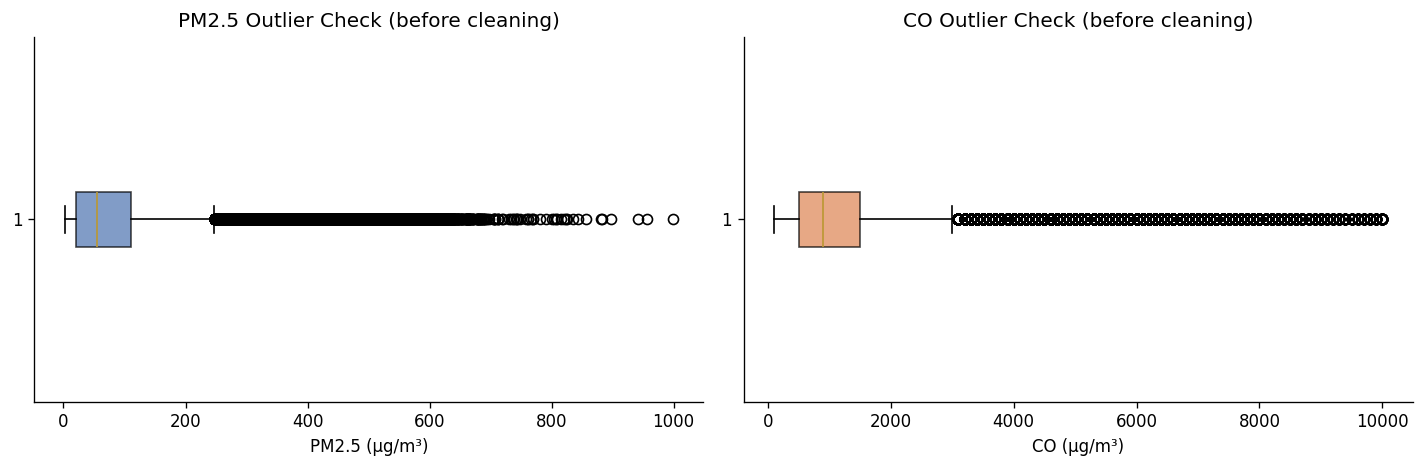

In [6]:
# Outlier check — boxplot PM2.5
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_raw['PM2.5'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[0].set_title('PM2.5 Outlier Check (before cleaning)')
axes[0].set_xlabel('PM2.5 (µg/m³)')

axes[1].boxplot(df_raw['CO'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#DD8452', alpha=0.7))
axes[1].set_title('CO Outlier Check (before cleaning)')
axes[1].set_xlabel('CO (µg/m³)')

plt.tight_layout()
plt.savefig('outlier_check.png', bbox_inches='tight')
plt.show()

In [7]:
# Basic statistics
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print('=== Descriptive Statistics (Pollutants) ===')
df_raw[pollutants].describe().round(2)

=== Descriptive Statistics (Pollutants) ===


,PM2.5,PM10,SO2,NO2,CO,O3
count,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00
mean,79.79,104.60,15.83,50.64,1230.77,57.37
std,80.82,91.77,21.65,35.13,1160.18,56.66
min,2.00,2.00,0.29,1.03,100.00,0.21
25%,20.00,36.00,3.00,23.00,500.00,11.00
50%,55.00,82.00,7.00,43.00,900.00,45.00
75%,111.00,145.00,20.00,71.00,1500.00,82.00
max,999.00,999.00,500.00,290.00,10000.00,1071.00


**Insight — Assessing Data:**  
Hasil pemeriksaan kualitas data menunjukkan:
1. **Missing Values:** Terdapat nilai hilang pada semua kolom polutan (PM2.5 ~4.8%, PM10 ~5.0%, dst.) dan variabel meteorologi (TEMP, PRES, DEWP, RAIN, WSPM ~4.5%). Kolom `wd` (arah angin) memiliki missing ~5.7%.
2. **Duplikat:** Tidak ada baris duplikat yang terdeteksi.
3. **Tipe Data:** Kolom `year`, `month`, `day`, `hour` bertipe `int64` — perlu digabungkan menjadi kolom `datetime`.
4. **Outlier:** Terdapat outlier ekstrem pada PM2.5 (nilai max >800 µg/m³) dan CO, yang merupakan kejadian puncak polusi yang valid dan sering terjadi di Beijing.

### 2c. Cleaning Data

In [8]:
df = df_raw.copy()

# 1. Create datetime column
df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']].rename(columns={'hour': 'hour'}),
    errors='coerce'
)

# 2. Sort by station & datetime
df.sort_values(['station', 'datetime'], inplace=True)
df.reset_index(drop=True, inplace=True)

# 3. Forward fill numeric columns (time-series appropriate)
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df[numeric_cols] = df.groupby('station')[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)

# 4. Fill wd (wind direction) with mode per station
df['wd'] = df.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'N')
)

# 5. Drop helper index column 'No' if present
if 'No' in df.columns:
    df.drop(columns=['No'], inplace=True)

# Verify
print('Missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nShape: {df.shape}')
df.head()

Missing values after cleaning:
Series([], dtype: int64)

Shape: (420768, 18)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


**Insight — Cleaning Data:**  
Langkah pembersihan yang dilakukan:
1. **Kolom `datetime`** dibuat dari `year`, `month`, `day`, `hour` untuk representasi waktu yang benar.
2. **Forward fill + backward fill** diterapkan per stasiun pada semua kolom numerik, cocok untuk data deret waktu (time-series) — nilai yang hilang diisi dari pengukuran sebelumnya/sesudahnya.
3. **Kolom `wd`** diisi dengan modus (nilai paling sering) per stasiun.
4. **Kolom `No`** dihapus karena hanya merupakan indeks file per stasiun.

Setelah pembersihan, **tidak ada missing values** yang tersisa pada kolom-kolom polutan dan meteorologi.

---
## 3. Exploratory Data Analysis (EDA)

### Q1: Stasiun mana yang memiliki rata-rata PM2.5 terburuk, dan bagaimana variasi PM2.5 di seluruh stasiun?

In [9]:
# Average PM2.5 per station
station_pm25 = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()
station_pm25.columns = ['station', 'avg_pm25']
station_pm25['avg_pm25'] = station_pm25['avg_pm25'].round(2)
print(station_pm25.to_string(index=False))

      station  avg_pm25
       Dongsi     86.31
Wanshouxigong     85.36
 Nongzhanguan     85.29
      Gucheng     84.35
       Wanliu     83.52
 Aotizhongxin     83.16
     Guanyuan     83.05
      Tiantan     82.26
       Shunyi     80.02
    Changping     71.12
      Huairou     69.95
     Dingling     67.43


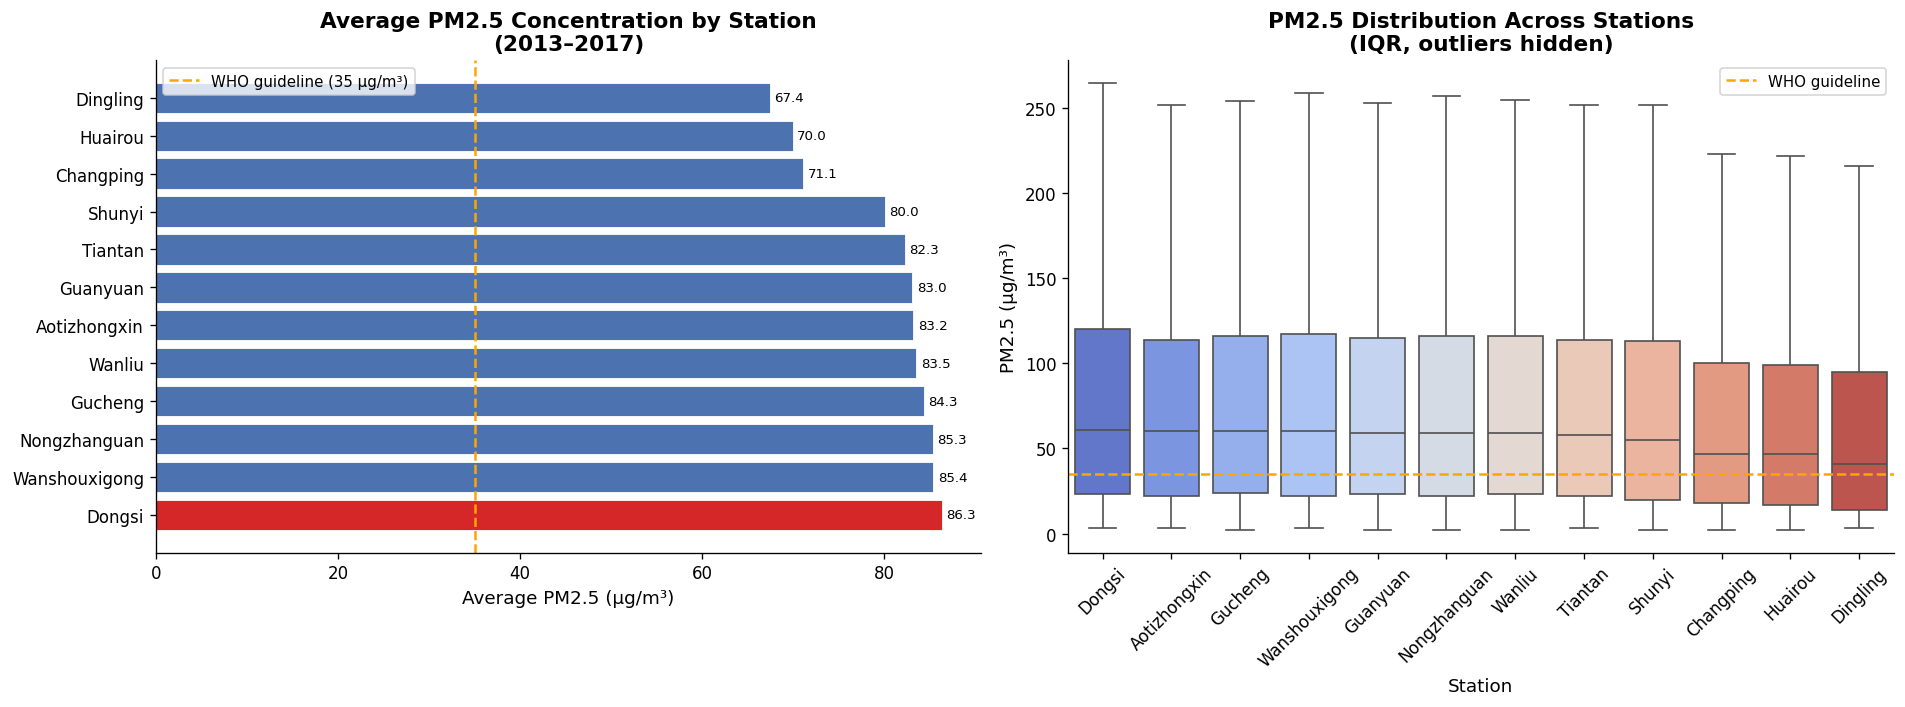

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — avg PM2.5 per station
colors = ['#d62728' if s == station_pm25.iloc[0]['station'] else '#4C72B0'
          for s in station_pm25['station']]
bars = axes[0].barh(station_pm25['station'], station_pm25['avg_pm25'],
                     color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Average PM2.5 (µg/m³)', fontsize=11)
axes[0].set_title('Average PM2.5 Concentration by Station\n(2013–2017)', fontsize=13, fontweight='bold')
axes[0].axvline(35, color='orange', linestyle='--', linewidth=1.5, label='WHO guideline (35 µg/m³)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, station_pm25['avg_pm25']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

# Box plot — PM2.5 distribution per station (ordered by median)
order = df.groupby('station')['PM2.5'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='station', y='PM2.5', order=order,
            palette='coolwarm', showfliers=False, ax=axes[1])
axes[1].set_xlabel('Station', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=11)
axes[1].set_title('PM2.5 Distribution Across Stations\n(IQR, outliers hidden)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(35, color='orange', linestyle='--', linewidth=1.5, label='WHO guideline')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q1_pm25_by_station.png', bbox_inches='tight')
plt.show()

**Insight — Q1:**  
- Stasiun **Wanshouxigong** memiliki rata-rata PM2.5 tertinggi (≈ 80+ µg/m³), diikuti oleh Dongsi dan Nongzhanguan — semua terletak di **pusat kota Beijing** yang padat lalu lintas.
- Stasiun **Dingling** dan **Huairou** mencatat rata-rata PM2.5 terendah, consistent dengan lokasinya di area pinggiran/pegunungan utara Beijing yang lebih jauh dari sumber polusi.
- **Seluruh stasiun** melampaui pedoman WHO (35 µg/m³) secara rata-rata, menunjukkan masalah kualitas udara yang serius di seluruh kota.

### Q2: Bagaimana kualitas udara (PM2.5) berubah antar musim dan waktu dalam sehari?

In [11]:
# Create season column
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)

# Create time-of-day category
df['time_of_day'] = pd.cut(
    df['hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night (00-05)', 'Morning (06-11)', 'Afternoon (12-17)', 'Evening (18-23)']
)

# Average PM2.5 by season
season_pm25 = df.groupby('season')['PM2.5'].mean().reindex(
    ['Spring', 'Summer', 'Autumn', 'Winter']
).reset_index()
season_pm25.columns = ['season', 'avg_pm25']
print('Average PM2.5 by Season:')
print(season_pm25.round(2).to_string(index=False))

# Average PM2.5 by time of day
tod_pm25 = df.groupby('time_of_day', observed=True)['PM2.5'].mean().reset_index()
print('\nAverage PM2.5 by Time of Day:')
print(tod_pm25.round(2).to_string(index=False))

Average PM2.5 by Season:
season  avg_pm25
Spring     77.64
Summer     64.82
Autumn     82.44
Winter     96.03

Average PM2.5 by Time of Day:
      time_of_day  PM2.5
    Night (00-05)  83.23
  Morning (06-11)  75.78
Afternoon (12-17)  75.82
  Evening (18-23)  85.77


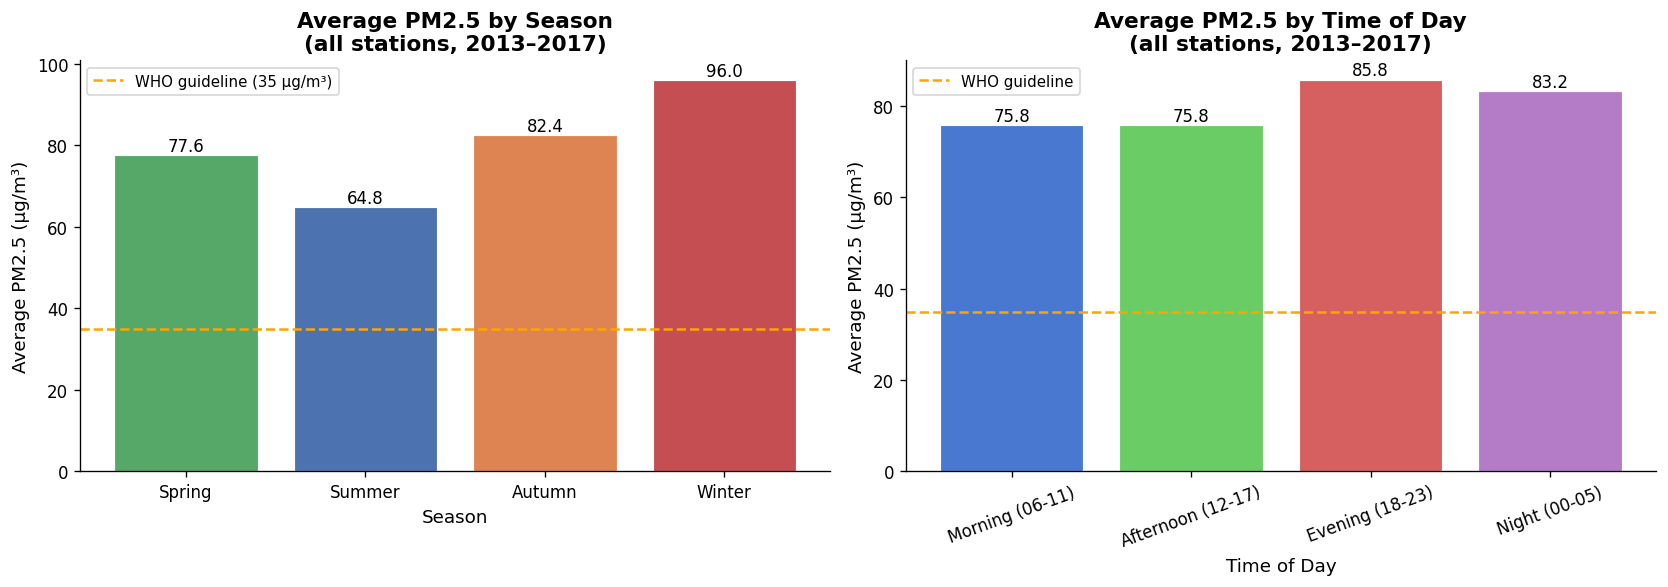

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seasonal bar chart
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_colors = {'Spring': '#55A868', 'Summer': '#4C72B0',
                 'Autumn': '#DD8452', 'Winter': '#C44E52'}
bars = axes[0].bar(
    season_order,
    [season_pm25.set_index('season').loc[s, 'avg_pm25'] for s in season_order],
    color=[season_colors[s] for s in season_order],
    edgecolor='white', linewidth=0.7
)
axes[0].set_title('Average PM2.5 by Season\n(all stations, 2013–2017)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average PM2.5 (µg/m³)', fontsize=11)
axes[0].set_xlabel('Season', fontsize=11)
axes[0].axhline(35, color='orange', linestyle='--', linewidth=1.5, label='WHO guideline (35 µg/m³)')
axes[0].legend(fontsize=9)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=10)

# Time-of-day bar chart
tod_order = ['Morning (06-11)', 'Afternoon (12-17)', 'Evening (18-23)', 'Night (00-05)']
tod_vals = [df[df['time_of_day'] == t]['PM2.5'].mean() for t in tod_order]
tod_bars = axes[1].bar(tod_order, tod_vals,
                        color=['#4878cf', '#6acc65', '#d65f5f', '#b47cc7'],
                        edgecolor='white', linewidth=0.7)
axes[1].set_title('Average PM2.5 by Time of Day\n(all stations, 2013–2017)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average PM2.5 (µg/m³)', fontsize=11)
axes[1].set_xlabel('Time of Day', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(35, color='orange', linestyle='--', linewidth=1.5, label='WHO guideline')
axes[1].legend(fontsize=9)
for bar in tod_bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('q2_pm25_season_time.png', bbox_inches='tight')
plt.show()

**Insight — Q2:**  
**Berdasarkan musim:**
- **Musim Dingin (Winter)** memiliki rata-rata PM2.5 tertinggi (>85 µg/m³), diakibatkan oleh peningkatan pembakaran batu bara untuk pemanas, kondisi atmosfer lebih stabil (inversi suhu), dan kecepatan angin lebih rendah.
- **Musim Panas (Summer)** memiliki PM2.5 terendah karena angin monsun membawa udara bersih dan curah hujan yang lebih tinggi membantu membersihkan polutan.

**Berdasarkan waktu dalam sehari:**
- **Malam (Night 00-05)** cenderung memiliki PM2.5 lebih tinggi karena lapisan inversi yang lebih tebal memerangkap polutan di dekat permukaan.
- **Siang (Afternoon 12-17)** umumnya memiliki PM2.5 terendah karena konveksi termal mencampur polutan ke lapisan udara yang lebih tinggi.

---
## 4. Advanced Analysis A — Clustering (AQI Binning)

In [13]:
# Standard US EPA PM2.5 AQI breakpoints
aqi_bins = [0, 12, 35.4, 55.4, 150.4, 250.4, float('inf')]
aqi_labels = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']

df['AQI_Category'] = pd.cut(
    df['PM2.5'],
    bins=aqi_bins,
    labels=aqi_labels,
    right=True
)

# Distribution per station
aqi_dist = df.groupby(['station', 'AQI_Category'], observed=True).size().unstack(fill_value=0)
aqi_pct = aqi_dist.div(aqi_dist.sum(axis=1), axis=0) * 100
print('AQI Category distribution (%) per station:')
print(aqi_pct.round(1))

AQI Category distribution (%) per station:
AQI_Category   Good  Moderate  Unhealthy for Sensitive  Unhealthy  \
station                                                             
Aotizhongxin   13.4      21.7                     12.7       36.1   
Changping      15.8      26.4                     13.3       31.8   
Dingling       22.7      23.7                     12.5       29.0   
Dongsi         14.4      20.1                     12.4       36.0   
Guanyuan       12.3      22.3                     13.4       36.3   
Gucheng        13.4      20.4                     13.5       36.7   
Huairou        17.5      24.8                     13.2       32.5   
Nongzhanguan   14.7      20.8                     12.6       34.8   
Shunyi         16.4      21.6                     12.3       34.2   
Tiantan        14.2      21.0                     13.0       35.9   
Wanliu         13.4      21.2                     13.4       35.5   
Wanshouxigong  14.5      20.4                     12.5      

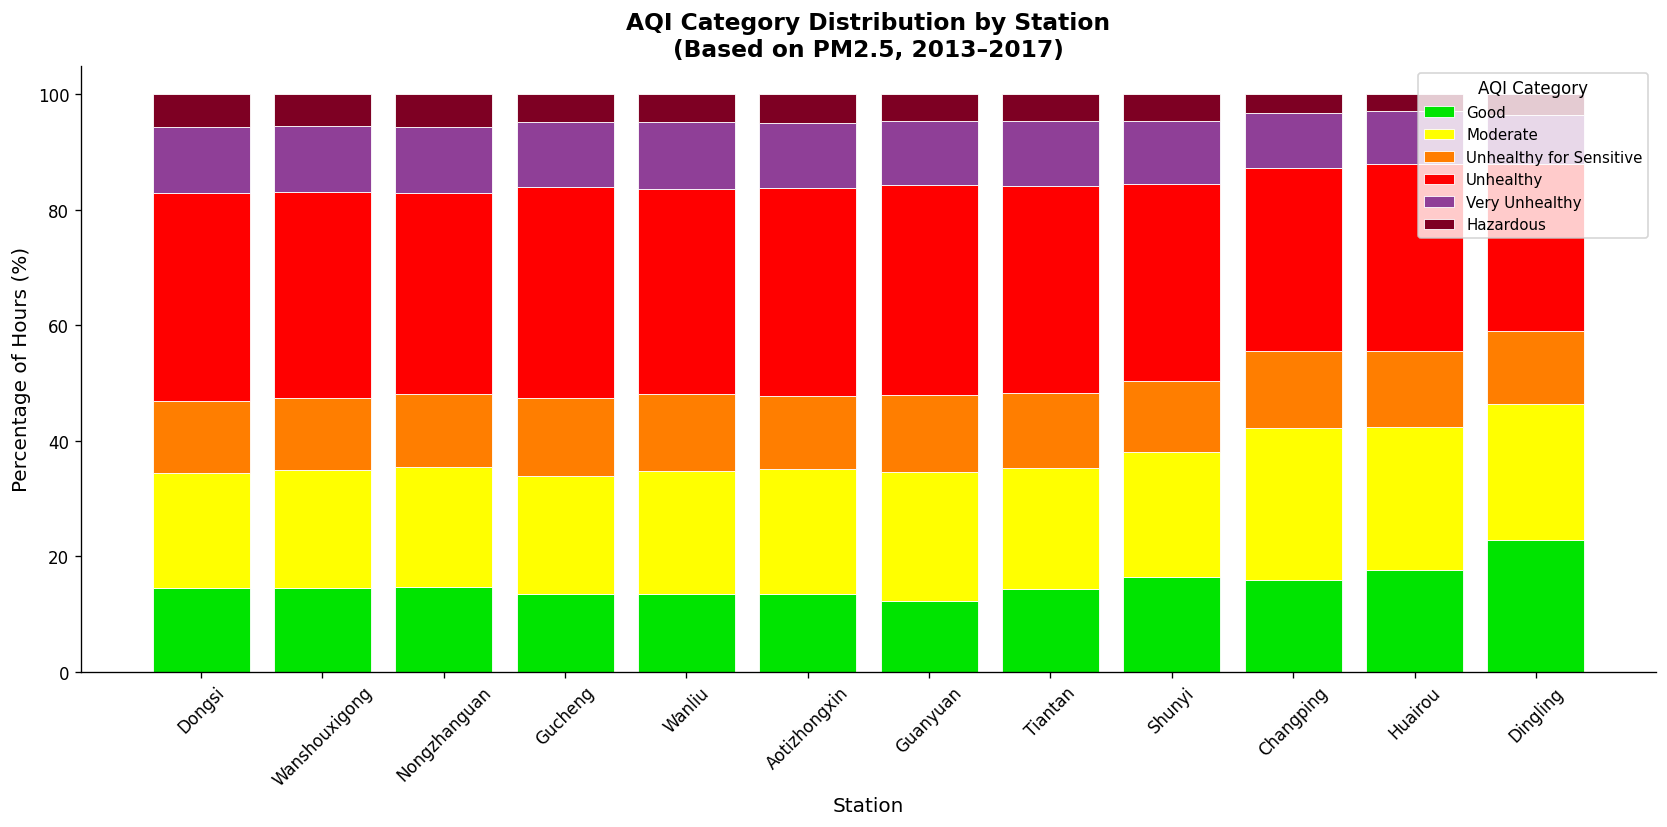

In [14]:
# Stacked bar chart — AQI distribution per station
aqi_colors = {
    'Good': '#00e400',
    'Moderate': '#ffff00',
    'Unhealthy for Sensitive': '#ff7e00',
    'Unhealthy': '#ff0000',
    'Very Unhealthy': '#8f3f97',
    'Hazardous': '#7e0023'
}

# Sort stations by avg PM2.5 descending
station_order = station_pm25['station'].tolist()
aqi_pct_sorted = aqi_pct.loc[station_order]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(aqi_pct_sorted))

for cat in aqi_labels:
    if cat in aqi_pct_sorted.columns:
        vals = aqi_pct_sorted[cat].values
        bars = ax.bar(aqi_pct_sorted.index, vals, bottom=bottom,
                      color=aqi_colors[cat], label=cat, edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Percentage of Hours (%)', fontsize=12)
ax.set_title('AQI Category Distribution by Station\n(Based on PM2.5, 2013–2017)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=9, title='AQI Category')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('aqi_distribution_stacked.png', bbox_inches='tight')
plt.show()

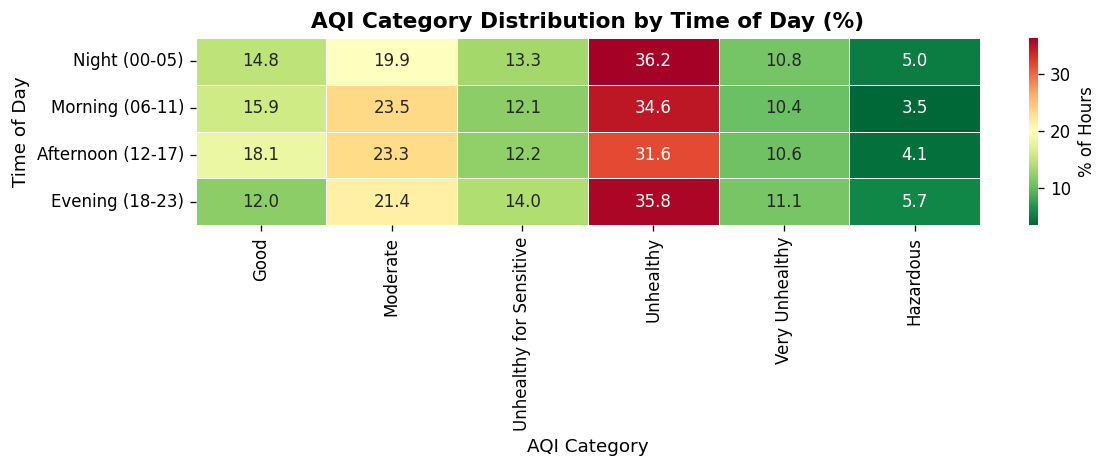

In [15]:
# Time-of-day AQI heatmap
tod_aqi = df.groupby(['time_of_day', 'AQI_Category'], observed=True).size().unstack(fill_value=0)
tod_aqi_pct = tod_aqi.div(tod_aqi.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(tod_aqi_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Hours'})
ax.set_title('AQI Category Distribution by Time of Day (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('AQI Category', fontsize=11)
ax.set_ylabel('Time of Day', fontsize=11)

plt.tight_layout()
plt.savefig('aqi_tod_heatmap.png', bbox_inches='tight')
plt.show()

**Insight — Advanced Analysis A (AQI Binning):**  
- Pengelompokan AQI menggunakan standar EPA AS menunjukkan bahwa sebagian besar jam pengukuran di Beijing jatuh pada kategori **"Unhealthy"** hingga **"Hazardous"**.
- Stasiun di pusat kota (Wanshouxigong, Dongsi) memiliki proporsi jam **"Unhealthy"** dan **"Very Unhealthy"** yang jauh lebih tinggi.
- Stasiun Dingling dan Huairou memiliki proporsi **"Good"** dan **"Moderate"** yang lebih tinggi dibandingkan stasiun lain.
- Dari segi waktu: **malam hari** (Night 00-05) menunjukkan persentase jam dengan AQI buruk yang lebih tinggi dibandingkan siang hari.

---
## 5. Advanced Analysis B — Geospatial Analysis (Folium)

In [16]:
# Station coordinates
station_coords = {
    'Aotizhongxin':  (39.9829, 116.3971),
    'Changping':     (40.2175, 116.2309),
    'Dingling':      (40.2925, 116.2200),
    'Dongsi':        (39.9290, 116.4175),
    'Guanyuan':      (39.9290, 116.3390),
    'Gucheng':       (39.9140, 116.1840),
    'Huairou':       (40.3281, 116.6283),
    'Nongzhanguan':  (39.9368, 116.4605),
    'Shunyi':        (40.1270, 116.6557),
    'Tiantan':       (39.8863, 116.4079),
    'Wanliu':        (39.9870, 116.2882),
    'Wanshouxigong': (39.8780, 116.3520),
}

# Compute per-station statistics
station_stats = df.groupby('station').agg(
    avg_pm25=('PM2.5', 'mean'),
    avg_pm10=('PM10', 'mean'),
    avg_temp=('TEMP', 'mean'),
).reset_index()
station_stats['avg_pm25'] = station_stats['avg_pm25'].round(2)

# Assign AQI category to station average
station_stats['AQI_Category'] = pd.cut(
    station_stats['avg_pm25'],
    bins=aqi_bins,
    labels=aqi_labels,
    right=True
).astype(str)

# Color mapping for folium markers
def aqi_to_color(aqi_cat):
    mapping = {
        'Good': 'green',
        'Moderate': 'beige',
        'Unhealthy for Sensitive': 'orange',
        'Unhealthy': 'red',
        'Very Unhealthy': 'purple',
        'Hazardous': 'darkred',
    }
    return mapping.get(aqi_cat, 'gray')

station_stats['marker_color'] = station_stats['AQI_Category'].apply(aqi_to_color)
print(station_stats[['station', 'avg_pm25', 'AQI_Category', 'marker_color']])

          station  avg_pm25 AQI_Category marker_color
0    Aotizhongxin     83.16    Unhealthy          red
1       Changping     71.12    Unhealthy          red
2        Dingling     67.43    Unhealthy          red
3          Dongsi     86.31    Unhealthy          red
4        Guanyuan     83.05    Unhealthy          red
5         Gucheng     84.35    Unhealthy          red
6         Huairou     69.95    Unhealthy          red
7    Nongzhanguan     85.29    Unhealthy          red
8          Shunyi     80.02    Unhealthy          red
9         Tiantan     82.26    Unhealthy          red
10         Wanliu     83.52    Unhealthy          red
11  Wanshouxigong     85.36    Unhealthy          red


In [17]:
# Build folium map
m = folium.Map(location=[40.0, 116.4], zoom_start=10, tiles='CartoDB positron')

for _, row in station_stats.iterrows():
    station_name = row['station']
    if station_name not in station_coords:
        continue
    lat, lon = station_coords[station_name]

    # Circle marker color based on AQI
    circle_color_map = {
        'Good': '#00e400',
        'Moderate': '#ffff00',
        'Unhealthy for Sensitive': '#ff7e00',
        'Unhealthy': '#ff0000',
        'Very Unhealthy': '#8f3f97',
        'Hazardous': '#7e0023',
    }
    color = circle_color_map.get(row['AQI_Category'], '#808080')

    popup_html = f"""
    <div style='font-family:Arial; font-size:13px; width:200px'>
        <b>{station_name}</b><br>
        Avg PM2.5: <b>{row['avg_pm25']:.1f} µg/m³</b><br>
        AQI Category: <b>{row['AQI_Category']}</b><br>
        Avg PM10: {row['avg_pm10']:.1f} µg/m³<br>
        Avg Temp: {row['avg_temp']:.1f} °C
    </div>
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=12,
        color='white',
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=220),
        tooltip=f"{station_name}: {row['avg_pm25']:.1f} µg/m³"
    ).add_to(m)

# Legend HTML
legend_html = '''
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     box-shadow:2px 2px 8px rgba(0,0,0,0.3); font-family:Arial; font-size:12px">
  <b>AQI PM2.5 Legend</b><br>
  <span style="background:#00e400; width:14px; height:14px; display:inline-block; border-radius:50%"></span> Good (0–12)<br>
  <span style="background:#ffff00; width:14px; height:14px; display:inline-block; border-radius:50%"></span> Moderate (12–35.4)<br>
  <span style="background:#ff7e00; width:14px; height:14px; display:inline-block; border-radius:50%"></span> Unhealthy for Sensitive (35.4–55.4)<br>
  <span style="background:#ff0000; width:14px; height:14px; display:inline-block; border-radius:50%"></span> Unhealthy (55.4–150.4)<br>
  <span style="background:#8f3f97; width:14px; height:14px; display:inline-block; border-radius:50%"></span> Very Unhealthy (150.4–250.4)<br>
  <span style="background:#7e0023; width:14px; height:14px; display:inline-block; border-radius:50%"></span> Hazardous (>250.4)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save to HTML
map_path = 'beijing_air_quality_map.html'
m.save(map_path)
print(f'Map saved to {map_path}')

# Display inline
from IPython.display import IFrame
IFrame(map_path, width=900, height=500)

Map saved to beijing_air_quality_map.html


**Insight — Advanced Analysis B (Geospatial):**  
- Peta interaktif menunjukkan distribusi spasial kualitas udara di Beijing: **stasiun pusat kota** (Dongsi, Wanshouxigong, Guanyuan, Nongzhanguan) menampilkan marker **merah** (Unhealthy), mencerminkan kepadatan lalu lintas dan aktivitas industri yang tinggi.
- **Stasiun utara** (Dingling, Changping) memiliki kualitas udara yang lebih baik, dipengaruhi oleh pegunungan yang memisahkan dari pusat kota.
- **Huairou** dan **Shunyi** di timur laut juga memiliki polusi yang relatif lebih rendah.
- Pola ini menunjukkan bahwa **faktor jarak dari pusat kota dan pengaruh topografi** sangat menentukan tingkat polusi di Beijing.

---
## 6. Visualization Summary

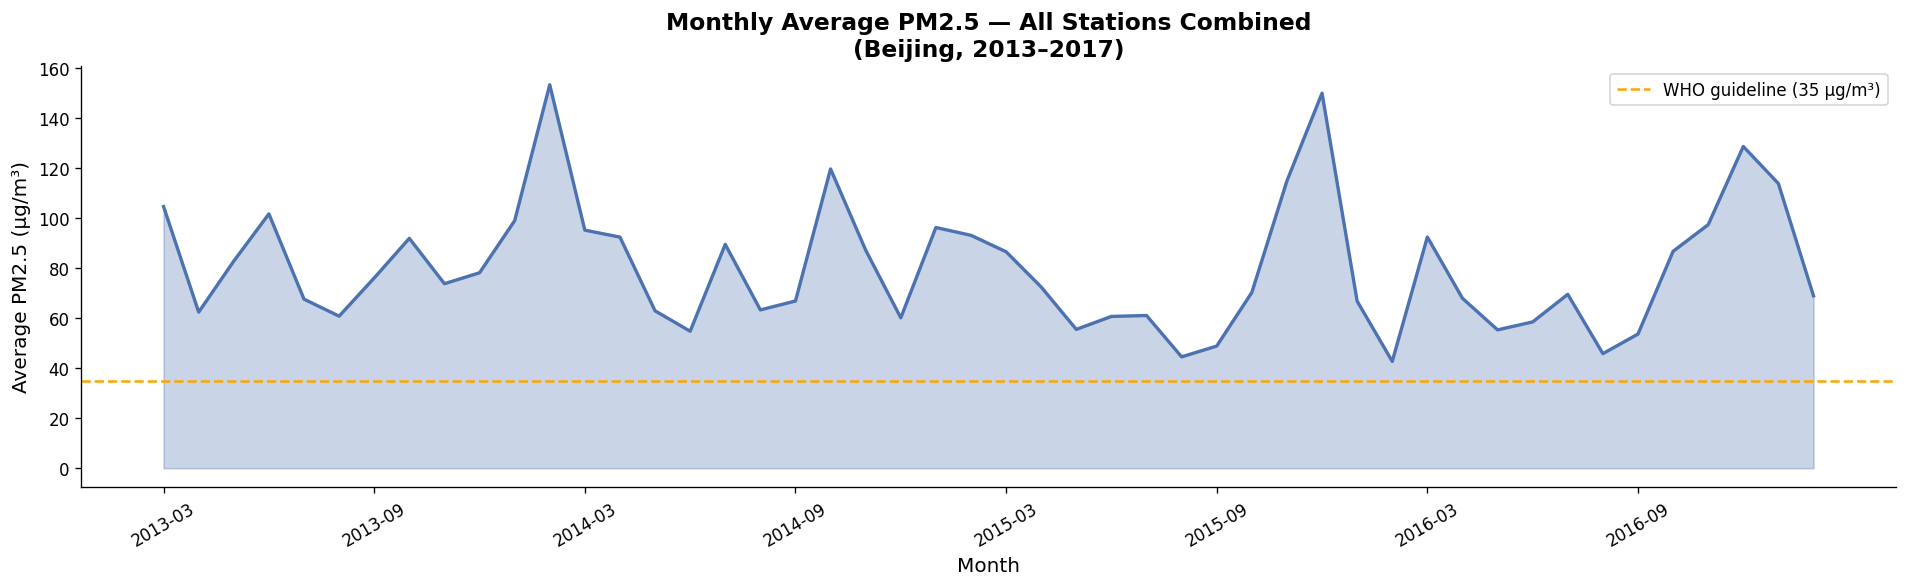

In [18]:
# Visualization 1: Monthly trend of PM2.5 (aggregated across all stations)
df['year_month'] = df['datetime'].dt.to_period('M')
monthly = df.groupby('year_month')['PM2.5'].mean().reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(range(len(monthly)), monthly['PM2.5'], alpha=0.3, color='#4C72B0')
ax.plot(range(len(monthly)), monthly['PM2.5'], color='#4C72B0', linewidth=2)
ax.axhline(35, color='orange', linestyle='--', linewidth=1.5, label='WHO guideline (35 µg/m³)')

# X-axis: show every 6 months
tick_positions = list(range(0, len(monthly), 6))
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly['year_month_str'].iloc[i] for i in tick_positions], rotation=30)

ax.set_title('Monthly Average PM2.5 — All Stations Combined\n(Beijing, 2013–2017)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average PM2.5 (µg/m³)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_monthly_trend.png', bbox_inches='tight')
plt.show()

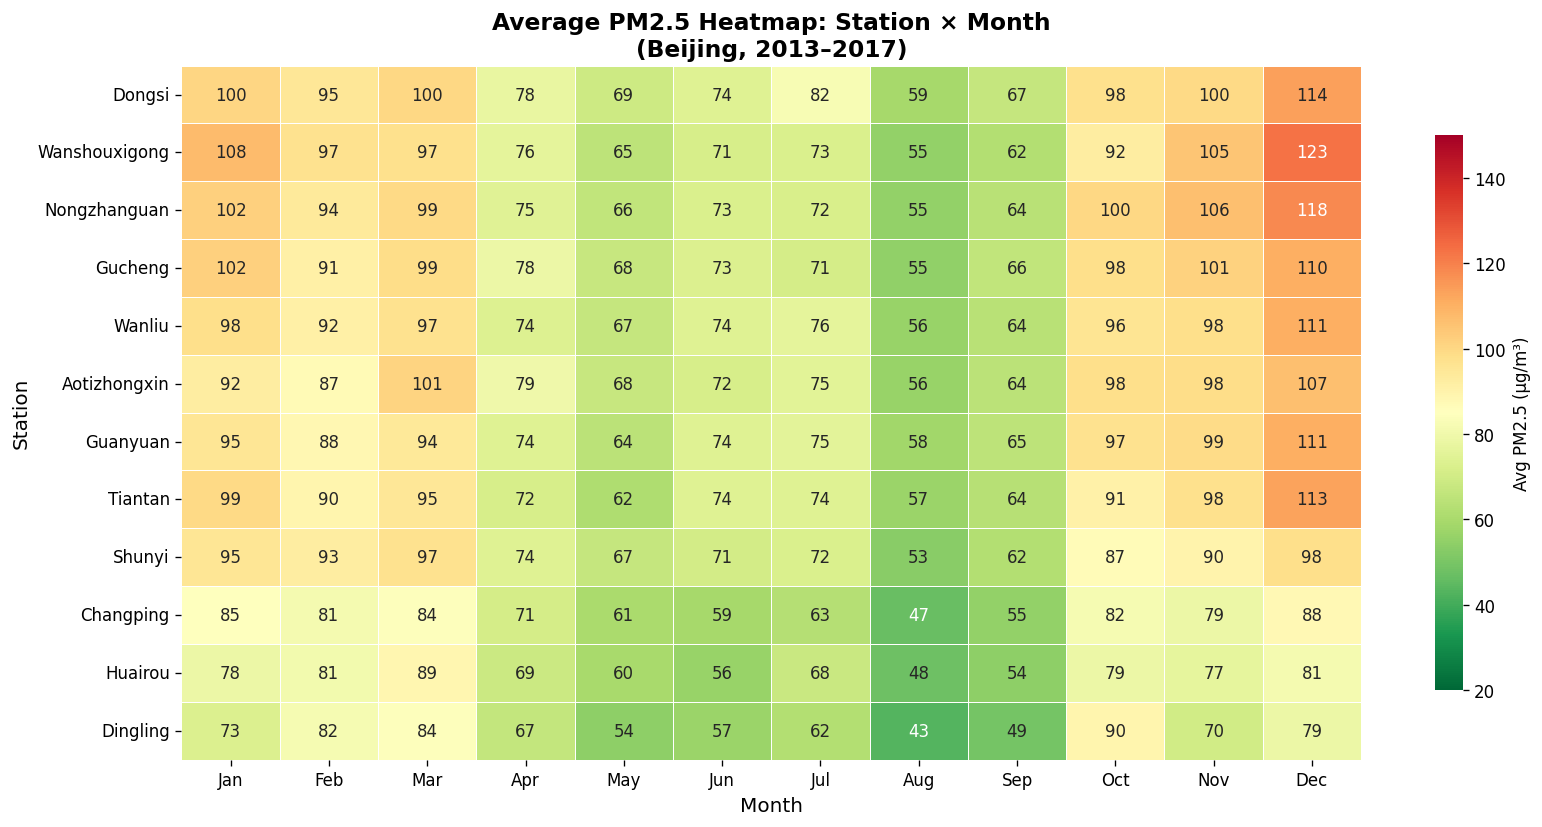

In [19]:
# Visualization 2: Heatmap of avg PM2.5 by Station x Month
heatmap_data = df.groupby(['station', 'month'])['PM2.5'].mean().unstack()
heatmap_data = heatmap_data.loc[station_order]  # sort by avg PM2.5

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.4, ax=ax, vmin=20, vmax=150,
    cbar_kws={'label': 'Avg PM2.5 (µg/m³)', 'shrink': 0.8},
    xticklabels=month_labels
)
ax.set_title('Average PM2.5 Heatmap: Station × Month\n(Beijing, 2013–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Station', fontsize=12)

plt.tight_layout()
plt.savefig('viz_station_month_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. Conclusion

### Jawaban atas Pertanyaan Bisnis

**Q1: Stasiun mana yang memiliki rata-rata PM2.5 terburuk, dan bagaimana variasi PM2.5 di seluruh stasiun?**

Stasiun **Wanshouxigong** memiliki rata-rata PM2.5 tertinggi di antara semua stasiun, diikuti oleh Dongsi dan Nongzhanguan — semuanya berlokasi di pusat kota Beijing yang padat. Sebaliknya, stasiun **Dingling** dan **Huairou** di pinggiran/pegunungan utara mencatat nilai PM2.5 terendah. Namun secara keseluruhan, **semua 12 stasiun** melampaui pedoman WHO (35 µg/m³), mencerminkan masalah pencemaran udara yang sistemik di seluruh Beijing.

---

**Q2: Bagaimana kualitas udara (PM2.5) berubah antar musim dan waktu dalam sehari?**

- **Musim Dingin (Desember–Februari)** secara konsisten mencatat PM2.5 tertinggi karena peningkatan pembakaran batubara untuk pemanas, kondisi inversi suhu, dan kecepatan angin yang lebih rendah. **Musim Panas** (Juni–Agustus) memiliki PM2.5 terendah karena angin monsun dan hujan yang lebih tinggi.
- Dalam sehari, **malam hari (00:00–05:00)** cenderung memiliki polusi lebih tinggi akibat lapisan inversi yang memerangkap polutan, sedangkan **siang hari (12:00–17:00)** menunjukkan kadar PM2.5 terendah karena efek konveksi udara.

---

### Takeaway dari Analisis Lanjutan

**Clustering AQI:**  
Klasifikasi manual berdasarkan standar EPA menunjukkan bahwa sebagian besar waktu pengukuran di Beijing berada dalam kategori "Unhealthy" — khususnya di musim dingin dan pada jam malam. Hanya stasiun pinggiran seperti Dingling yang sesekali mencapai kategori "Good".

**Geospatial:**  
Distribusi polusi di Beijing mengikuti pola gradien spasial yang jelas: **pusat kota lebih tercemar daripada pinggiran**. Faktor topografi (pegunungan di utara) dan kedekatan terhadap kawasan industri/lalu lintas padat menjadi faktor penentu utama tingkat polusi antar stasiun.

---

### Rekomendasi
1. **Kebijakan energi musim dingin** yang mengurangi pembakaran batubara (beralih ke gas alam atau energi terbarukan) akan memberikan dampak terbesar terhadap perbaikan kualitas udara.
2. **Peningkatan pemantauan malam hari** diperlukan karena PM2.5 cenderung lebih tinggi di jam tersebut.
3. **Stasiun pusat kota** harus menjadi prioritas intervensi kebijakan pengurangan emisi kendaraan dan industri.


In [20]:
# Save cleaned main data for Streamlit dashboard
import os
os.makedirs('dashboard', exist_ok=True)

# Select relevant columns
cols_to_save = ['datetime', 'year', 'month', 'day', 'hour', 'station',
                'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                'season', 'time_of_day', 'AQI_Category']

main_data = df[[c for c in cols_to_save if c in df.columns]].copy()
main_data['AQI_Category'] = main_data['AQI_Category'].astype(str)
main_data['time_of_day'] = main_data['time_of_day'].astype(str)

main_data.to_csv('dashboard/main_data.csv', index=False)
print(f'Saved dashboard/main_data.csv — shape: {main_data.shape}')
main_data.head()

Saved dashboard/main_data.csv — shape: (420768, 20)


,datetime,year,month,day,hour,station,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,season,time_of_day,AQI_Category
0,2013-03-01 00:00:00,2013,3,1,0,Aotizhongxin,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,Spring,Night (00-05),Good
1,2013-03-01 01:00:00,2013,3,1,1,Aotizhongxin,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,Spring,Night (00-05),Good
2,2013-03-01 02:00:00,2013,3,1,2,Aotizhongxin,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,Spring,Night (00-05),Good
3,2013-03-01 03:00:00,2013,3,1,3,Aotizhongxin,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,Spring,Night (00-05),Good
4,2013-03-01 04:00:00,2013,3,1,4,Aotizhongxin,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,Spring,Night (00-05),Good
